# Modelos de Machine Learning

## Introdução

A previsão de séries temporais tem sido tradicionalmente dominada por modelos estatísticos clássicos como ARIMA e SARIMA. No entanto, com a evolução do Machine Learning (ML), surgiram novas abordagens capazes de lidar com padrões complexos, relações não lineares e grandes volumes de dados.

Ao aplicar Machine Learning em séries temporais, é necessário reformular o problema de previsão para um formato de aprendizagem supervisionada. Isso implica transformar a série temporal em conjuntos de features (variáveis independentes) e targets (variável dependente), muitas vezes utilizando defasagens (*lags*) e janelas de tempo (*rolling windows*).

Neste notebook, vamos explorar três abordagens de Machine Learning aplicadas a séries temporais:
- **Random Forest**
- **XGBoost**
- **LSTM**

Cada modelo apresenta características únicas, vantagens e desafios, os quais serão apresentados de forma teórica e prática.




## Modelos Teóricos

### Random Forest

O Random Forest é um algoritmo de aprendizagem supervisionada baseado em árvores de decisão. Ele cria múltiplas árvores durante o treino e produz a média das previsões individuais para melhorar a precisão e controlar o overfitting.

**Vantagens:**
- Robusto contra overfitting.
- Funciona bem com datasets de alta dimensionalidade.
- Pouco sensível a valores extremos e dados ruidosos.

**Limitações:**
- Não modela diretamente a dependência temporal.
- Pode ser menos eficiente em dados sequenciais se não forem criadas features adequadas (lags, tendências).

### XGBoost

O XGBoost (Extreme Gradient Boosting) é um algoritmo de boosting de árvores que corrige os erros dos modelos anteriores de forma iterativa, gerando previsões mais precisas.

**Vantagens:**
- Alta performance em termos de precisão e velocidade.
- Inclui regularização, o que ajuda a evitar overfitting.
- Eficiente em capturar relações não lineares complexas.

**Limitações:**
- Exige maior esforço de afinação dos hiperparâmetros.
- Também não modela naturalmente a componente temporal dos dados.

### LSTM

As LSTM (Long Short-Term Memory) são um tipo especial de Redes Neuronais Recorrentes (RNN) desenvolvidas para aprender dependências de longo prazo em dados sequenciais.

**Vantagens:**
- Capacidade de capturar padrões de dependência temporal de curto e longo prazo.
- Indicado para séries temporais altamente complexas e com variações dinâmicas.

**Limitações:**
- Requer maior capacidade computacional e mais dados para treino eficiente.
- Necessita de cuidado especial na preparação dos dados (normalização e reshaping).

Neste notebook, iremos demonstrar a aplicação prática destes modelos em séries temporais, comparando o seu desempenho e discutindo as suas principais diferenças.

## Preparação dos Dados

A aplicação de modelos de Machine Learning a séries temporais requer uma adaptação prévia dos dados, transformando o problema sequencial num problema de aprendizagem supervisionada tradicional.


### Criação de Features

Em séries temporais, é comum utilizar valores passados (defasagens ou *lags*) como variáveis independentes para prever valores futuros. Este processo é conhecido como **Feature engineering**.

Exemplo de criação de features:
- Lag de 1 período (`t-1`): valor imediatamente anterior.
- Lag de 2 períodos (`t-2`): valor dois passos atrás.
- Rolling Mean: média móvel dos últimos n períodos.
- Rolling Std: desvio padrão móvel dos últimos n períodos.

A escolha do número de lags e de janelas de agregação deve ser feita com base na natureza do problema e análise dos dados.

### Separação dos Dados

Após a criação das features, é necessário dividir os dados em conjuntos de treino e teste, respeitando a ordem temporal para evitar fugas de informação (*data leakage*).

- **Conjunto de treino**: utilizado para treinar os modelos.
- **Conjunto de teste**: utilizado para avaliar a capacidade de generalização dos modelos.

**Nota**: nunca devemos utilizar *shuffle* (embaralhamento) nas séries temporais.

### Normalização dos Dados

Para modelos baseados em árvores (Random Forest e XGBoost), a normalização dos dados **não é obrigatória**. Estes algoritmos são insensíveis às escalas das variáveis.

No entanto, para redes neuronais (LSTM), a normalização ou padronização dos dados é fundamental para garantir uma convergência eficiente durante o treino.

As técnicas mais comuns incluem:
- **Min-Max Scaling**: transforma os dados para um intervalo [0, 1].
- **Standard Scaling**: transforma os dados para terem média 0 e desvio padrão 1.

### Estrutura dos Dados para LSTM

O modelo LSTM espera os dados num formato tridimensional:
- **Samples**: número de observações.
- **Timesteps**: número de passos de tempo por amostra.
- **Features**: número de variáveis.

Assim, depois de criar as features, será necessário remodelar (reshape) o conjunto de dados antes de treinar o LSTM.

## Preparação dos Dados para Modelos de Machine Learning

Vamos preparar o dataset "AirPassengers.csv" para aplicar os modelos de Machine Learning.

O objetivo é transformar a série temporal num problema de aprendizagem supervisionada, criando features adequadas e separando os dados em treino e teste de forma correta.


In [1]:
# Importação das bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import LSTM, Dense # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Ler o dataset
df = pd.read_csv('./Datasets/AirPassengers.csv', parse_dates=['Month'], index_col='Month')

# Mudar o nome da coluna '#Passengers'
df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Visualizar os primeiros 5 registos
df.head()


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [3]:
# Criação de Features Temporais (lags)

# Criar lags de 1, 2 e 3 meses
df['lag_1'] = df['Passengers'].shift(1)
df['lag_2'] = df['Passengers'].shift(2)
df['lag_3'] = df['Passengers'].shift(3)

# Remover linhas com valores NaN gerados pelas os lags
df = df.dropna()

# Visualizar os dados preparados
df.head()


,Passengers,lag_1,lag_2,lag_3
Month,,,,
1949-04-01,129,132.0,118.0,112.0
1949-05-01,121,129.0,132.0,118.0
1949-06-01,135,121.0,129.0,132.0
1949-07-01,148,135.0,121.0,129.0
1949-08-01,148,148.0,135.0,121.0


In [4]:
# Definir as variáveis independentes (features) e a variável dependente (target)
X = df[['lag_1', 'lag_2', 'lag_3']]
y = df[['Passengers']]


In [5]:
# Separação em Conjuntos de Treino e Teste
# train = 80% do tamanho da série original
# teste = 20% do tamanho da série original
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # type: ignore

# Confirmar as dimensões
print(f"Treino: X{X_train.shape}, y{y_train.shape}")
print(f"Teste: X{X_test.shape}, y{y_test.shape}")


Treino: X(112, 3), y(112, 1)
Teste: X(29, 3), y(29, 1)


### Observações

- Para *Random Forest* e *XGBoost*, não é necessário normalizar as variáveis.
- Para o modelo LSTM é necessário normalizar mas só será feita quando formos utilizar o modelo.

### Modelo - Random Forest Regressor

In [6]:
# Criação do modelo Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100,       # número de árvores
                                 max_depth=None,         # profundidade máxima das árvores
                                 random_state=42,        # para reprodutibilidade
                                 n_jobs=-1)              # usar todos os núcleos do CPU

# Treinar o modelo
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
# Previsões
y_pred_rf = rf_model.predict(X_test)

# Calcular as métricas
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Avaliação do modelo
print(f"Random Forest - RMSE: {rmse_rf:.2f}")
print(f"Random Forest - MAE: {mae_rf:.2f}")
print(f"Random Forest - R2: {r2_rf:.2f}")

Random Forest - RMSE: 76.24
Random Forest - MAE: 58.35
Random Forest - R2: 0.05


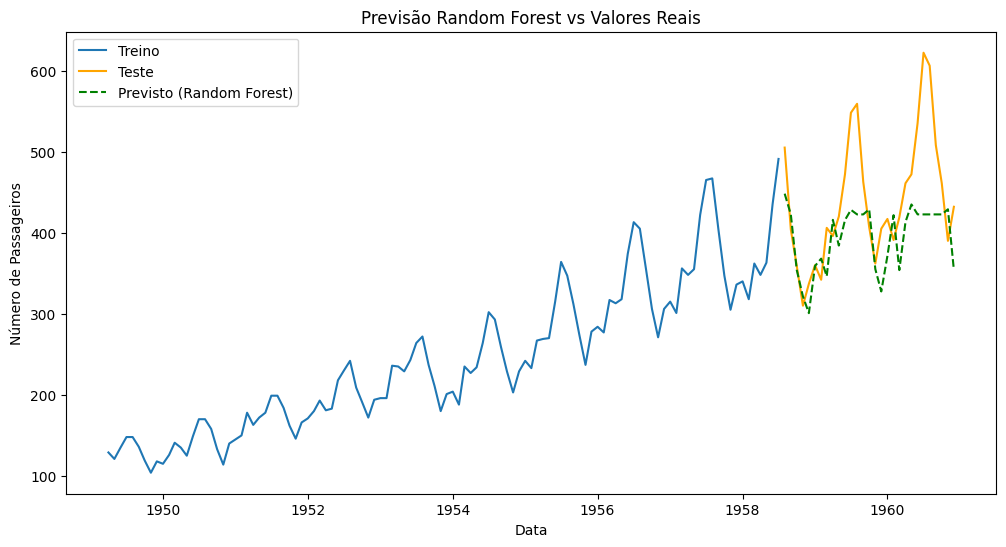

In [8]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(X_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label='Teste', color='orange')
plt.plot(y_test.index, y_pred_rf, label='Previsto (Random Forest)', color='green', linestyle='--')
plt.title('Previsão Random Forest vs Valores Reais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

### Modelo - XGBRegressor

In [9]:
# Criação do modelo XGBRegressor
xgb_model = XGBRegressor(n_estimators=100,        # número de árvores (boosting rounds)
                         learning_rate=0.1,       # taxa de aprendizagem (default: 0.3 → reduzimos para melhorar estabilidade)
                         max_depth=3,             # profundidade máxima das árvores
                         subsample=0.8,           # amostra de 80% dos dados em cada árvore (ajuda a reduzir overfitting)
                         colsample_bytree=0.8,    # amostra de 80% das features em cada árvore
                         random_state=42)         # para reprodutibilidade

# Treinar o modelo
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
# Previsões
y_pred_xgb = xgb_model.predict(X_test)

# Calcular as métricas
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Avaliação do modelo
print(f"XGBoost - RMSE: {rmse_xgb:.2f}")
print(f"XGBoost - MAE: {mae_xgb:.2f}")
print(f"XGBoost - R2: {r2_xgb:.2f}")

XGBoost - RMSE: 92.00
XGBoost - MAE: 69.56
XGBoost - R2: -0.39


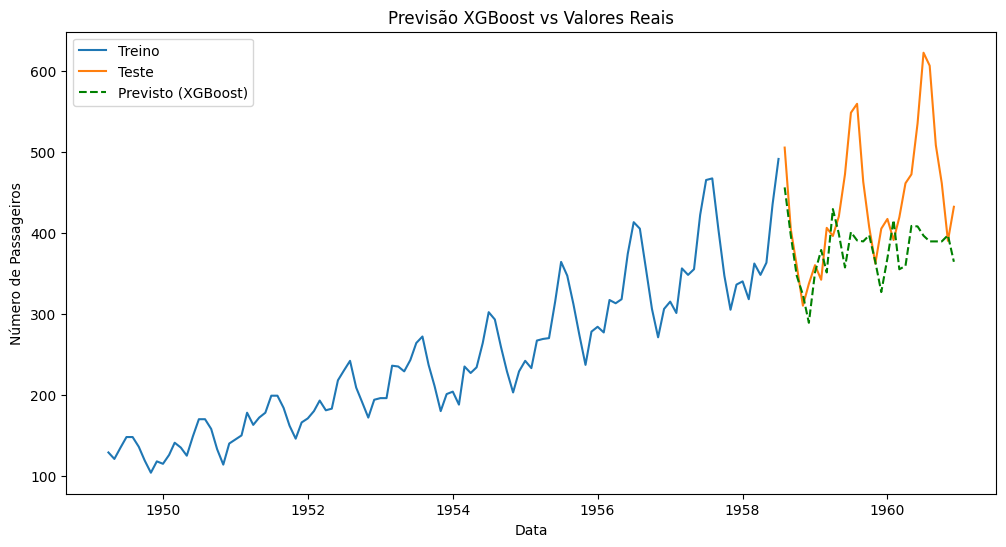

In [11]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(12,6))
plt.plot(X_train.index, y_train, label="Treino")
plt.plot(y_test.index, y_test, label='Teste')
plt.plot(y_test.index, y_pred_xgb, label='Previsto (XGBoost)', color='green', linestyle='--')
plt.title('Previsão XGBoost vs Valores Reais')
plt.xlabel('Data')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

### Modelo - LSTM

In [12]:
'''Como foi dito anteriormente o modelo LSTM necessita que o dados sejam normalizados antes de utilizar o modelo.
É o que vamos fazer a seguir. Normalização e reshape dos dataframes (x, y).'''

# Outra maneira de dividir o dataset
# Definir o tamanho do conjunto de treino
train_size = int(len(df) * 0.8)

# Dividir dados primeiro
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Normalizadores
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Normalizar apenas com base no treino para evitar data leakage
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Reformular para o formato [samples, time_steps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Confirmar as novas formas
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")


X_train_lstm shape: (112, 1, 3)
X_test_lstm shape: (29, 1, 3)


In [13]:
# Definir o modelo LSTM
model_lstm = Sequential()

# Adicionar a camada LSTM
model_lstm.add(LSTM(units=50,  # Neurónios
                    activation='tanh',  # Função de ativação - tangente hiperbólica
                    input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

# Adicionar camada de saída
model_lstm.add(Dense(1))

# Optimizador - Adapta o learning rate automaticamente.
optimizer = Adam(learning_rate=0.001)

# Compilar o modelo
model_lstm.compile(optimizer=optimizer, loss='mean_squared_error')

# Resumo do modelo
model_lstm.summary()

# Treinar o modelo
history_lstm = model_lstm.fit(X_train_lstm,
                              y_train_scaled,
                              epochs=100,  # Nº de vezes que o modelo irá "ver" o conjunto de treino completo.
                              batch_size=16,  # Nº de amostras processadas antes de atualizar os pesos do modelo.
                              validation_split=0.1,  # Separar 10% do treino para validação
                              verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,851 (42.39 KB)

 Trainable params: 10,851 (42.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.1058 - val_loss: 0.3267
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0777 - val_loss: 0.2537
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0626 - val_loss: 0.1916
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0503 - val_loss: 0.1415
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0352 - val_loss: 0.1011
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0213 - val_loss: 0.0723
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0153 - val_loss: 0.0519
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0126 - val_loss: 0.0385
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0112 - val_loss: 0.0327
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0112 - val_loss: 0.0299
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0120 - val_loss: 0.0297
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0134 - val_lo

In [14]:
# Avaliação do Modelo LSTM
'''Agora vamos avaliar o modelo LSTM:
        - Fazer previsões nos dados de teste;
        - Inverter a normalização para os valores originais;
        - Calcular métricas de desempenho;
        - Visualizar os resultados.'''

# Previsões
y_pred_scaled = model_lstm.predict(X_test_lstm)

# Inverter a normalização
y_train_original = scaler_y.inverse_transform(y_train_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_scaled)

# Cálculo das métricas
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Mean Squared Error (MSE): 4011.82
Root Mean Squared Error (RMSE): 63.34
Mean Absolute Error (MAE): 50.01
R² Score: 0.3428


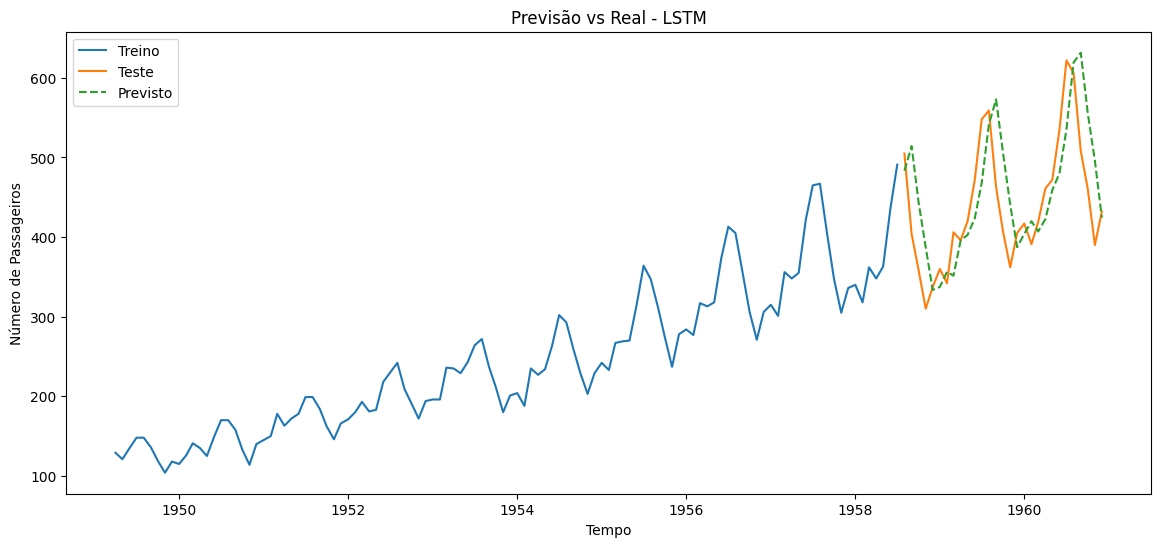

In [15]:
# Gráfico das previsões vs valores reais
plt.figure(figsize=(14,6))
plt.plot(y_train.index, y_train_original, label="Treino")
plt.plot(y_test.index, y_test_original, label='Teste')
plt.plot(y_test.index, y_pred, label='Previsto', linestyle='--')
plt.title('Previsão vs Real - LSTM')
plt.xlabel('Tempo')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.show()

### Observações

- __SARIMA__ - O modelo SARIMA apresentou o melhor ajuste entre todos os modelos. Consegue seguir os valores reais com elevada precisão, inclusive nos picos sazonais. Visualmente, a linha prevista quase se sobrepõe à real — coerente com os menores valores de erro (MAE e RMSE).

- __LSTM__ - A rede LSTM segue bem a tendência dos dados e apresenta boa capacidade de prever variações sazonais. No entanto, nota-se um desvio nos picos e vales em alguns períodos, o que pode justificar o RMSE mais elevado. Ainda assim, é um resultado bastante competitivo para dados temporais.

- __XGBoost__ - O XGBoost teve o pior desempenho. A linha prevista aparece "achatada" e pouco sensível às variações reais dos dados. Este comportamento confirma os valores elevados de erro (MAE e RMSE), sendo visível que o modelo tem dificuldade em capturar a sazonalidade.

- __Random Forest__ - O modelo Random Forest consegue acompanhar a tendência geral, mas suaviza bastante os picos, falhando nas variações bruscas. É visível que a curva prevista não atinge os máximos ou mínimos reais. O desempenho é ligeiramente melhor que o do XGBoost, mas inferior ao LSTM e ao SARIMA.

Entre os quatro modelos, SARIMA destaca-se claramente como o melhor modelo para este conjunto de dados temporais, tanto em termos visuais como quantitativos.

Modelos baseados em machine learning como LSTM e Random Forest têm potencial, especialmente se forem bem ajustados ou complementados com feature engineering adicional. No entanto, neste caso concreto, um modelo estatístico tradicional como SARIMA foi mais eficaz na captura da estrutura temporal dos dados.

### Próximos Passos

Ainda existe espaço para melhorias, nomeadamente:
- Ajuste e tuning de hiperparâmetros;
- Aplicação de cross-validation;
- Uso de engenharia de features temporais, como mês, tendência, lag features, etc.

Estes pontos serão explorados no próximo notebook, dedicado à avaliação e otimização dos modelos.